#Install Library

In [ ]:
pip install youtube-comment-downloader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 6.8 MB/s eta 0:00:00


In [ ]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.0 MB/s eta 0:00:00


In [ ]:
pip install transformers torch

#Import Library

In [ ]:
from youtube_comment_downloader import YoutubeCommentDownloader
pd.set_option('display.max_colwidth', None)

In [ ]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import nltk
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer
import string
import nltk
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import nltk
from nltk.corpus import stopwords as nltk_stopwords

nltk.download('punkt')
nltk.download('stopwords')

stopword_id = set(nltk_stopwords.words('indonesian'))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Scrapping

In [ ]:
from numpy import common_type
downloader = YoutubeCommentDownloader()
url = "https://www.youtube.com/watch?v=LRTNTrBxF1g"
comments = []
for comment in downloader.get_comments_from_url(url):
    comments.append(comment)
    if len(comments) >= 2000:
        break
df_youtube = pd.DataFrame(comments)

#Read Data

In [ ]:
df_youtube

,cid,text,time,author,channel,votes,replies,photo,heart,reply,time_parsed
0,Ugxtb9_iUziqhxlD79N4AaABAg,ambisinya jadi presiden dan keliling2 kenalan ke negara2lain biar tampak gagah...tapi kok kelihatan memalukan bagi rakyat indonesia !!,1 hour ago,@mastur2215,UCE7j6s9dD159cYL1KQio1Qw,0,,https://yt3.ggpht.com/ytc/AIdro_k0PVo4Ayjzf9FlRcdjZAQYBwK430_hLvWlP9jgikQjC65W-ONDWjkk4dykteuHJ96HgQ=s88-c-k-c0x00ffffff-no-rj,False,False,1.781675e+09
1,UgzhKaNMZOOS0hxccv54AaABAg,Dia pamer kebodohannya sendiri...,5 hours ago,@masnurchanify,UCwl_lwhNe7yH2p9FByDMzWA,0,,https://yt3.ggpht.com/ytc/AIdro_kzynw9LqU7tm7smJ7QvMrHFrZA_1D9F8RCca_audk=s88-c-k-c0x00ffffff-no-rj,False,False,1.781660e+09
2,UgyLd1tsnQEjOi09Wdh4AaABAg,Wowo itu naif makanya gampang dibegoin anak buahnya,1 day ago,@ibnunizar1902,UCO9c0QinhjOCTkQv9iqQPZw,0,,https://yt3.ggpht.com/ytc/AIdro_llZo_hI4yQKdgeBut-hOi-I5J3v2190m-9wZw9LZu_uQ=s88-c-k-c0x00ffffff-no-rj,False,False,1.781592e+09
3,UgzoTKZ9600-hmoCUHx4AaABAg,"KAN EMANG BODOH PLUS TOLOL BANG.KALAU GAK IDIOT MANA MUNGKIN GAK TAU ADA ORANG MALING 1M PERHARI GAK TAU,APALAGI SAMPAI JENJANG WAKTU SELAMA INI.",1 day ago,@JOSSINKRI1945,UCoSg58oGSgG7Hofh2UvjjJQ,0,,https://yt3.ggpht.com/Py_wTZoS_pnBBWvgNONrEfTkgCc4CBuXUSkXxoiujtG_zyKbkb6KNYA32BEuSRs_uVoSIoH-=s88-c-k-c0x00ffffff-no-rj,False,False,1.781592e+09
4,UgwI6W7QiTRznGvl02J4AaABAg,"Fix bego itu.. dah titik gapake koma..\n\nBukan bohong, karena emang dia gatau (bohong)..\n\nOrang2 disekitar nya itu takut ngebrief bos nya.. karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh",1 day ago (edited),@muhammadangga358,UCTj3JYIg9wcs5DVqSmku4Rg,0,,https://yt3.ggpht.com/aQROWPUyg2zm--kbSd2b-IcAtcRBAvGDd0PIPvaFcuBdxwLksw-3M5QXHJm0kT1mKic9T7ER7X8=s88-c-k-c0x00ffffff-no-rj,False,False,1.781592e+09
...,...,...,...,...,...,...,...,...,...,...,...
1995,Ugwez4glJmqojCG_49x4AaABAg,Kenapa kalau bicara gerak bibirnya kayak cewek ya....masih jantan kah dia?,3 weeks ago,@piye_meneh,UCHSCJ2qJHgYP-vakLnANt0A,0,,https://yt3.ggpht.com/ytc/AIdro_kHaW8Z3uXwI83EcCIr30_G0BxFzR13kqLi6O0epDRUBbFKcrlzQtJw1GAwojpPuyl88Q=s88-c-k-c0x00ffffff-no-rj,False,False,1.779864e+09
1996,Ugyu3TT8D8sVD2O_c2R4AaABAg,"Judul seperti ini jelas tidak etis dan hanya bertujuan menghina, bukan berdiskusi sehat.",3 weeks ago,@ruam5016,UCph7xai80qA-Sj_F_3QHTXA,0,,https://yt3.ggpht.com/I-qSUq1aMduho6gQWeoYaHDOVM-Crxe1Trla2YNjIHU6ypd9407NFROvrPACpy-UliYLE1Te_XQ=s88-c-k-c0x00ffffff-no-rj,False,False,1.779864e+09
1997,UgxwRZqpLZmD5CQF1Mp4AaABAg,Pembisik : TT- TD - HS,3 weeks ago,@mochtarbintaro,UCwLYzFKpvtvusKOYnTnr43g,0,,https://yt3.ggpht.com/ytc/AIdro_kjND8U1TiPEw_nk7wHVRzjEfaU_vW2mZ6uU0PTBL6yiuvUWRvQQNsfIOn_RS_2JkLdcA=s88-c-k-c0x00ffffff-no-rj,False,False,1.779864e+09
1998,UgwV1tfWajKt-kZNhsF4AaABAg,BODOH ATAU BOHONG .... KEDUANYA MAUUUUTTT,3 weeks ago,@cinemabox-t6o,UCCNcY-Iq9xcmECsdv3Dbz-g,0,,https://yt3.ggpht.com/ytc/AIdro_nBDeZ9mqdIFB9ZVjY1L_Zestnzoo5Sf1l4wqCS9M9x7GOn4Ieia6TOKEF-97zhMtLXgw=s88-c-k-c0x00ffffff-no-rj,False,False,1.779864e+09


In [ ]:
df_youtube = df_youtube[['text']].copy()

#EDA

In [ ]:
df_youtube.isnull().sum()

,0
text,0


In [ ]:
df_youtube.duplicated().sum()

np.int64(16)

In [ ]:
df_youtube.drop_duplicates(inplace=True)

#Preprocessing

In [ ]:
def cleaning(text):

    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus hashtag
    text = re.sub(r'#\w+', '', text)

    # ganti titik menjadi spasi
    text = text.replace('.', ' ')

    # ganti underscore
    text = text.replace('_', ' ')

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus emoji
    text = re.sub(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        '',
        text,
        flags=re.UNICODE
    )

    # hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_youtube['cleaning'] = df_youtube['text'].apply(cleaning)

In [ ]:
df_youtube

,text,cleaning
0,ambisinya jadi presiden dan keliling2 kenalan ke negara2lain biar tampak gagah...tapi kok kelihatan memalukan bagi rakyat indonesia !!,ambisinya jadi presiden dan keliling kenalan ke negaralain biar tampak gagah tapi kok kelihatan memalukan bagi rakyat indonesia
1,Dia pamer kebodohannya sendiri...,Dia pamer kebodohannya sendiri
2,Wowo itu naif makanya gampang dibegoin anak buahnya,Wowo itu naif makanya gampang dibegoin anak buahnya
3,"KAN EMANG BODOH PLUS TOLOL BANG.KALAU GAK IDIOT MANA MUNGKIN GAK TAU ADA ORANG MALING 1M PERHARI GAK TAU,APALAGI SAMPAI JENJANG WAKTU SELAMA INI.",KAN EMANG BODOH PLUS TOLOL BANG KALAU GAK IDIOT MANA MUNGKIN GAK TAU ADA ORANG MALING M PERHARI GAK TAUAPALAGI SAMPAI JENJANG WAKTU SELAMA INI
4,"Fix bego itu.. dah titik gapake koma..\n\nBukan bohong, karena emang dia gatau (bohong)..\n\nOrang2 disekitar nya itu takut ngebrief bos nya.. karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh",Fix bego itu dah titik gapake koma Bukan bohong karena emang dia gatau bohong Orang disekitar nya itu takut ngebrief bos nya karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh
...,...,...
1995,Kenapa kalau bicara gerak bibirnya kayak cewek ya....masih jantan kah dia?,Kenapa kalau bicara gerak bibirnya kayak cewek ya masih jantan kah dia
1996,"Judul seperti ini jelas tidak etis dan hanya bertujuan menghina, bukan berdiskusi sehat.",Judul seperti ini jelas tidak etis dan hanya bertujuan menghina bukan berdiskusi sehat
1997,Pembisik : TT- TD - HS,Pembisik TT TD HS
1998,BODOH ATAU BOHONG .... KEDUANYA MAUUUUTTT,BODOH ATAU BOHONG KEDUANYA MAUUUUTTT


#Case Folding

In [ ]:
def case_folding(text):
    if isinstance(text, str):
      lowercase_text = text.lower()
      return lowercase_text
    else:
        return text

df_youtube['case_folding'] = df_youtube['cleaning'].apply(case_folding)
df_youtube

,text,cleaning,case_folding
0,ambisinya jadi presiden dan keliling2 kenalan ke negara2lain biar tampak gagah...tapi kok kelihatan memalukan bagi rakyat indonesia !!,ambisinya jadi presiden dan keliling kenalan ke negaralain biar tampak gagah tapi kok kelihatan memalukan bagi rakyat indonesia,ambisinya jadi presiden dan keliling kenalan ke negaralain biar tampak gagah tapi kok kelihatan memalukan bagi rakyat indonesia
1,Dia pamer kebodohannya sendiri...,Dia pamer kebodohannya sendiri,dia pamer kebodohannya sendiri
2,Wowo itu naif makanya gampang dibegoin anak buahnya,Wowo itu naif makanya gampang dibegoin anak buahnya,wowo itu naif makanya gampang dibegoin anak buahnya
3,"KAN EMANG BODOH PLUS TOLOL BANG.KALAU GAK IDIOT MANA MUNGKIN GAK TAU ADA ORANG MALING 1M PERHARI GAK TAU,APALAGI SAMPAI JENJANG WAKTU SELAMA INI.",KAN EMANG BODOH PLUS TOLOL BANG KALAU GAK IDIOT MANA MUNGKIN GAK TAU ADA ORANG MALING M PERHARI GAK TAUAPALAGI SAMPAI JENJANG WAKTU SELAMA INI,kan emang bodoh plus tolol bang kalau gak idiot mana mungkin gak tau ada orang maling m perhari gak tauapalagi sampai jenjang waktu selama ini
4,"Fix bego itu.. dah titik gapake koma..\n\nBukan bohong, karena emang dia gatau (bohong)..\n\nOrang2 disekitar nya itu takut ngebrief bos nya.. karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh",Fix bego itu dah titik gapake koma Bukan bohong karena emang dia gatau bohong Orang disekitar nya itu takut ngebrief bos nya karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh,fix bego itu dah titik gapake koma bukan bohong karena emang dia gatau bohong orang disekitar nya itu takut ngebrief bos nya karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh
...,...,...,...
1995,Kenapa kalau bicara gerak bibirnya kayak cewek ya....masih jantan kah dia?,Kenapa kalau bicara gerak bibirnya kayak cewek ya masih jantan kah dia,kenapa kalau bicara gerak bibirnya kayak cewek ya masih jantan kah dia
1996,"Judul seperti ini jelas tidak etis dan hanya bertujuan menghina, bukan berdiskusi sehat.",Judul seperti ini jelas tidak etis dan hanya bertujuan menghina bukan berdiskusi sehat,judul seperti ini jelas tidak etis dan hanya bertujuan menghina bukan berdiskusi sehat
1997,Pembisik : TT- TD - HS,Pembisik TT TD HS,pembisik tt td hs
1998,BODOH ATAU BOHONG .... KEDUANYA MAUUUUTTT,BODOH ATAU BOHONG KEDUANYA MAUUUUTTT,bodoh atau bohong keduanya mauuuuttt


#Tokenize

In [ ]:
def tokenize(text):
    tokens = text.split()
    return tokens

df_youtube['tokenize'] = df_youtube['case_folding'].apply(tokenize)
df_youtube

,text,cleaning,case_folding,tokenize
0,ambisinya jadi presiden dan keliling2 kenalan ke negara2lain biar tampak gagah...tapi kok kelihatan memalukan bagi rakyat indonesia !!,ambisinya jadi presiden dan keliling kenalan ke negaralain biar tampak gagah tapi kok kelihatan memalukan bagi rakyat indonesia,ambisinya jadi presiden dan keliling kenalan ke negaralain biar tampak gagah tapi kok kelihatan memalukan bagi rakyat indonesia,"[ambisinya, jadi, presiden, dan, keliling, kenalan, ke, negaralain, biar, tampak, gagah, tapi, kok, kelihatan, memalukan, bagi, rakyat, indonesia]"
1,Dia pamer kebodohannya sendiri...,Dia pamer kebodohannya sendiri,dia pamer kebodohannya sendiri,"[dia, pamer, kebodohannya, sendiri]"
2,Wowo itu naif makanya gampang dibegoin anak buahnya,Wowo itu naif makanya gampang dibegoin anak buahnya,wowo itu naif makanya gampang dibegoin anak buahnya,"[wowo, itu, naif, makanya, gampang, dibegoin, anak, buahnya]"
3,"KAN EMANG BODOH PLUS TOLOL BANG.KALAU GAK IDIOT MANA MUNGKIN GAK TAU ADA ORANG MALING 1M PERHARI GAK TAU,APALAGI SAMPAI JENJANG WAKTU SELAMA INI.",KAN EMANG BODOH PLUS TOLOL BANG KALAU GAK IDIOT MANA MUNGKIN GAK TAU ADA ORANG MALING M PERHARI GAK TAUAPALAGI SAMPAI JENJANG WAKTU SELAMA INI,kan emang bodoh plus tolol bang kalau gak idiot mana mungkin gak tau ada orang maling m perhari gak tauapalagi sampai jenjang waktu selama ini,"[kan, emang, bodoh, plus, tolol, bang, kalau, gak, idiot, mana, mungkin, gak, tau, ada, orang, maling, m, perhari, gak, tauapalagi, sampai, jenjang, waktu, selama, ini]"
4,"Fix bego itu.. dah titik gapake koma..\n\nBukan bohong, karena emang dia gatau (bohong)..\n\nOrang2 disekitar nya itu takut ngebrief bos nya.. karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh",Fix bego itu dah titik gapake koma Bukan bohong karena emang dia gatau bohong Orang disekitar nya itu takut ngebrief bos nya karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh,fix bego itu dah titik gapake koma bukan bohong karena emang dia gatau bohong orang disekitar nya itu takut ngebrief bos nya karena emang orang yg paling menakutkan adalah penguasa bodoh yang gapaham kalo dia itu bodoh,"[fix, bego, itu, dah, titik, gapake, koma, bukan, bohong, karena, emang, dia, gatau, bohong, orang, disekitar, nya, itu, takut, ngebrief, bos, nya, karena, emang, orang, yg, paling, menakutkan, adalah, penguasa, bodoh, yang, gapaham, kalo, dia, itu, bodoh]"
...,...,...,...,...
1995,Kenapa kalau bicara gerak bibirnya kayak cewek ya....masih jantan kah dia?,Kenapa kalau bicara gerak bibirnya kayak cewek ya masih jantan kah dia,kenapa kalau bicara gerak bibirnya kayak cewek ya masih jantan kah dia,"[kenapa, kalau, bicara, gerak, bibirnya, kayak, cewek, ya, masih, jantan, kah, dia]"
1996,"Judul seperti ini jelas tidak etis dan hanya bertujuan menghina, bukan berdiskusi sehat.",Judul seperti ini jelas tidak etis dan hanya bertujuan menghina bukan berdiskusi sehat,judul seperti ini jelas tidak etis dan hanya bertujuan menghina bukan berdiskusi sehat,"[judul, seperti, ini, jelas, tidak, etis, dan, hanya, bertujuan, menghina, bukan, berdiskusi, sehat]"
1997,Pembisik : TT- TD - HS,Pembisik TT TD HS,pembisik tt td hs,"[pembisik, tt, td, hs]"
1998,BODOH ATAU BOHONG .... KEDUANYA MAUUUUTTT,BODOH ATAU BOHONG KEDUANYA MAUUUUTTT,bodoh atau bohong keduanya mauuuuttt,"[bodoh, atau, bohong, keduanya, mauuuuttt]"


#Normalisasi Slang

In [ ]:
slang_dict = {
    'yg':'yang',
    'dg':'dengan',
    'dgn':'dengan',
    'bgn' :'bangun',
    'utk':'untuk',
    'sdh':'sudah',
    'udh':'sudah',
    'udah':'sudah',
    'blm':'belum',
    'sm':'sama',
    'krn':'karena',
    'dr':'dari',
    'trs':'terus',
    'lu' : 'kamu',
    'loe' : 'kamu',
    'lho' : 'kamu',
    'dpt':'dapat',
    'dapet':'dapat',
    'bkn':'bukan',
    'jd':'jadi',
    'jdi':'jadi',
    'bwt':'buat',
    'byr':'bayar',
    'pke':'pakai',
    'pkai':'pakai',
    'org':'orang',
    'ank':'anak',
    'ortu':'orang tua',
    'mrk':'mereka',
    'sy':'saya',
    'sya':'saya',
    'gw':'saya',
    'gua':'saya',
    'gue':'saya',
    'aq':'aku',
    'gk':'tidak',
    'ga':'tidak',
    'gak':'tidak',
    'nggak':'tidak',
    'ngga':'tidak',
    'enggak':'tidak',
    'tdk':'tidak',
    'bgt':'banget',
    'bngt':'banget',
    'bnget':'banget',
    'jgn':'jangan',
    'jngn':'jangan',
    'hr':'hari',
    'hri':'hari',
    'thn':'tahun',
    'bln':'bulan',
    'byk':'banyak',
    'bnyk':'banyak',
    'sdkt':'sedikit',
    'mnrt':'menurut',
    'pdhl':'padahal',
    'klu':'kalau',
    'kalo':'kalau',
    'klo':'kalau',
    'kl':'kalau',
    'tp':'tapi',
    'tpi':'tapi',
    'bs':'bisa',
    'bsa':'bisa',
    'aja':'saja',
    'doang':'saja',
    'smoga':'semoga',
    'moga':'semoga',
    'kyk':'seperti',
    'cm':'cuma',
    'cmn':'cuma',
     "yg":"yang",
    "gk":"tidak",
    "ga":"tidak",
    "nggak":"tidak",
    "tdk":"tidak",
    "bgt":"bangat",
    "krn":"karena",
    "jd":"jadi",
    "pdhl":"padahal",
    "udah":"sudah",
    "sdh":"sudah",
    "mbg" : "makan bergizi gratis",
    # politik & sosial
    'rkyt':'rakyat',
    'masyrkt':'masyarakat',
    'pemrintah':'pemerintah',
    'pmrintah':'pemerintah',

    'bpk':'bapak',
    'pak':'bapak',
    'bu':'ibu',
    'uu' : 'undang undang'
}

def normalize_slang(tokens):

    return [
        slang_dict[word] if word in slang_dict else word
        for word in tokens
    ]

df_youtube['normalize'] = df_youtube['tokenize'].apply(normalize_slang)

#Stopword Removal

In [ ]:
custom_stopwords = {
    'yg','aja','nya','sih','nih','dong',
    'lah','mah','kok','gak','ga','nggak',
    'udah','sdh','bgt','banget'
}
stopword_id.update(custom_stopwords)
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopword_id]
df_youtube['stopword'] = df_youtube['normalize'].apply(remove_stopwords)

#Stemming

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stemming(tokens):
  kalimat = ' '.join(tokens)
  return stemmer.stem(kalimat)
df_youtube['stemming'] = df_youtube['stopword'].apply(stemming)

#Sentiment Analysis

In [ ]:
classifier = pipeline("sentiment-analysis")
model = "wllwo/indonesian-roberta-base-sentiment-classifier"

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [ ]:
import pandas as pd
from transformers import pipeline
from tqdm import tqdm

# Load model sentiment analysis
classifier = pipeline(
    "sentiment-analysis",
    device=0  # gunakan -1 jika CPU
)

labels = []
scores = []

MAX_CHAR = 2000

for text in tqdm(df_youtube['stemming']):

    if pd.notnull(text):

        try:
            # Potong karakter yang terlalu panjang
            text = str(text)[:MAX_CHAR]

            result = classifier(
                text,
                truncation=True,
                max_length=512
            )[0]

            labels.append(result['label'])
            scores.append(result['score'])

        except Exception as e:

            print(f"Error pada teks: {str(e)}")

            labels.append('unknown')
            scores.append(0)

    else:

        labels.append('unknown')
        scores.append(0)

# Simpan hasil ke dataframe
df_youtube['sentiment'] = labels
df_youtube['sentiment_score'] = scores

# Lihat hasil
df_youtube[['stemming', 'sentiment', 'sentiment_score']].head()

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

100%|██████████| 1984/1984 [02:27<00:00, 13.50it/s]


,stemming,sentiment,sentiment_score
0,ambisi presiden keliling kenal negaralain biar gagah malu rakyat indonesia,NEGATIVE,0.773398
1,pamer bodoh,NEGATIVE,0.986410
2,wowo naif gampang dibegoin anak buah,NEGATIVE,0.574392
3,emang bodoh plus tolol bang idiot tau orang maling m hari tauapalagi jenjang,NEGATIVE,0.988174
4,fix bego dah titik gapake koma bohong emang gatau bohong orang sekitar takut ngebrief bos emang orang takut kuasa bodoh gapaham bodoh,NEGATIVE,0.998108


In [ ]:
df_youtube[['stemming','sentiment','sentiment_score']].head(20)

,stemming,sentiment,sentiment_score
0,ambisi presiden keliling kenal negaralain biar gagah malu rakyat indonesia,NEGATIVE,0.773398
1,pamer bodoh,NEGATIVE,0.986410
2,wowo naif gampang dibegoin anak buah,NEGATIVE,0.574392
3,emang bodoh plus tolol bang idiot tau orang maling m hari tauapalagi jenjang,NEGATIVE,0.988174
4,fix bego dah titik gapake koma bohong emang gatau bohong orang sekitar takut ngebrief bos emang orang takut kuasa bodoh gapaham bodoh,NEGATIVE,0.998108
5,gedabrus unungnya cari duit didptnya reformasi smpai skrg riring liberarlise adab timur perlahan hilang,NEGATIVE,0.989804
6,sby cerdas santun,POSITIVE,0.803337
7,terima kasih bang panji sedia rajin feedback tuntun berfikir bang panji orang indonesia cinta sungguh negara moga allah lindung jaga aamiin henti ya bang,NEGATIVE,0.878337
8,ud tua ud istirahat ud nikmatin hidup,NEGATIVE,0.982663
9,bohong bodoh lekat erat prabowo kombinasi rusa masif bobrok perintah negara orang brengsek kuasa bisnis jalan pikir apa untung pribadi bro villain sejati sejarah indonesia,NEGATIVE,0.944405


In [ ]:
df_youtube[['stemming','sentiment','sentiment_score']].tail(20)

,stemming,sentiment,sentiment_score
1980,bijak jalan komitmen presiden dorong maju ekonomi buka peluang rakyat,NEGATIVE,0.827180
1981,serang pribadi pimpin judul kualitas diskusi rendah,NEGATIVE,0.983572
1982,prabowo liat hebat mantu presiden,NEGATIVE,0.974518
1983,konten provokatif solusi besar polarisasi,NEGATIVE,0.763311
1984,diskusi politik sehat narasi hina serang pribadi,NEGATIVE,0.960610
1985,komedian geser kritikus spy ratingnya ya,NEGATIVE,0.983634
1986,thats the point tahun presiden kepala negara panglima tinggi ngomong tepok jidat bang pasrah,NEGATIVE,0.931616
1987,menteri kabinet gblok,NEGATIVE,0.892403
1988,buat konten sengaja cari sensasi pancing benci,NEGATIVE,0.981387
1989,prabowo bodoh gegara ngopinya campur mecin,NEGATIVE,0.987141


In [ ]:
df_youtube['sentiment'].value_counts()

,count
sentiment,
NEGATIVE,1648
POSITIVE,336


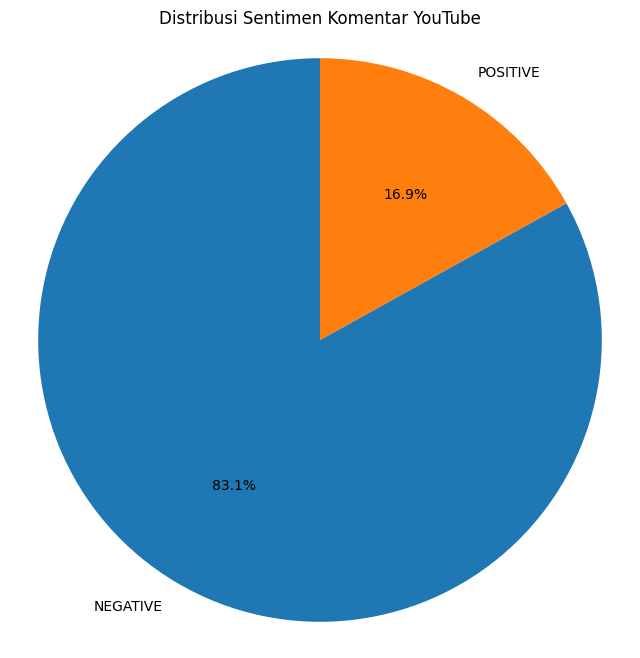

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df_youtube['sentiment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Sentimen Komentar YouTube')
plt.axis('equal')  # agar pie chart berbentuk lingkaran sempurna

plt.show()

#Split Data

In [ ]:
train_data, test_data, train_labels, test_labels = train_test_split(
    df_youtube['stemming'], df_youtube['sentiment'], test_size=0.2, random_state=42
)

In [ ]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_data)
X_test = vectorizer.transform(test_data)

In [ ]:
#vectorizer untuk mengubah ke angka

#Model Naive Bayes

In [ ]:
naive_bayes = MultinomialNB()
naive_bayes.fit(X_train, train_labels)
predictions = naive_bayes.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f'Accuracy: {accuracy}\n')
print(f"Classification Report:\n", report)

Accuracy: 0.8287153652392947

Classification Report:
               precision    recall  f1-score   support

    NEGATIVE       0.85      0.97      0.91       336
    POSITIVE       0.23      0.05      0.08        61

    accuracy                           0.83       397
   macro avg       0.54      0.51      0.49       397
weighted avg       0.75      0.83      0.78       397



#Decision Tree

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, train_labels)
predictions = dt.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f'Accuracy: {accuracy}\n')
print(f'Classification Report:\n{report}')

Accuracy: 0.6851385390428212

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.93      0.68      0.78       336
    POSITIVE       0.29      0.72      0.41        61

    accuracy                           0.69       397
   macro avg       0.61      0.70      0.60       397
weighted avg       0.83      0.69      0.73       397



#Random Forest

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
random_forest.fit(X_train, train_labels)
predictions = random_forest.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f'Accuracy: {accuracy:.4f}\n')
print(f'Classification Report:\n{report}')

Accuracy: 0.7179

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.93      0.72      0.81       336
    POSITIVE       0.31      0.70      0.43        61

    accuracy                           0.72       397
   macro avg       0.62      0.71      0.62       397
weighted avg       0.84      0.72      0.75       397



#Adaboost

In [ ]:
adaboost = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
adaboost.fit(X_train, train_labels)
predictions = adaboost.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f'Accuracy: {accuracy}\n')
print(f'Classification Report:\n{report}')

Accuracy: 0.8463476070528967

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.85      1.00      0.92       336
    POSITIVE       0.00      0.00      0.00        61

    accuracy                           0.85       397
   macro avg       0.42      0.50      0.46       397
weighted avg       0.72      0.85      0.78       397



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Logistic Regresi

In [ ]:
logistic_regression = LogisticRegression(
    random_state=42,
    max_iter=1000
)
logistic_regression.fit(X_train, train_labels)
predictions = logistic_regression.predict(X_test)
accuracy = accuracy_score(test_labels, predictions)
report = classification_report(test_labels, predictions)
print(f'Accuracy: {accuracy}\n')
print(f'Classification Report:\n{report}')

Accuracy: 0.8211586901763224

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.86      0.94      0.90       336
    POSITIVE       0.34      0.18      0.24        61

    accuracy                           0.82       397
   macro avg       0.60      0.56      0.57       397
weighted avg       0.78      0.82      0.80       397

